<a href="https://colab.research.google.com/github/szosszi/smwa/blob/main/games_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytrends

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime, timedelta
from pytrends.request import TrendReq

# Force Pandas to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Initialize Google Trends
pytrends = TrendReq(hl='en-US', tz=360, timeout=(10,25))

# 1. The NEW List of 10 Games requested by your colleagues
GAMES = [
    {"name": "Baldur's Gate 3", "appid": "1086940", "release_date": "2023-08-03"},
    {"name": "Palworld", "appid": "1623730", "release_date": "2024-01-19"},
    {"name": "Helldivers 2", "appid": "553850", "release_date": "2024-02-08"},
    {"name": "Black Myth Wukong", "appid": "2358720", "release_date": "2024-08-20"},
    {"name": "Manor Lords", "appid": "1363080", "release_date": "2024-04-26"},
    {"name": "Hades II", "appid": "1145350", "release_date": "2024-05-06"},
    {"name": "Elden Ring Shadow of the Erdtree", "appid": "2778580", "release_date": "2024-06-21"},
    {"name": "Satisfactory 1.0", "appid": "526870", "release_date": "2024-09-10"},
    {"name": "Path of Exile 2", "appid": "2694490", "release_date": "2024-12-06"},
    {"name": "Space Marine 2", "appid": "2183900", "release_date": "2024-09-09"}
]

# We use Minecraft as a massive, stable baseline to scale the 0-100 peaks
BENCHMARK = "Minecraft"

def get_steamspy_data(appid):
    """Downloads market data from SteamSpy."""
    url = f"https://steamspy.com/api.php?request=appdetails&appid={appid}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            return {
                'owners': data.get('owners', '0 .. 0'),
                'positive_reviews': data.get('positive', 0),
                'negative_reviews': data.get('negative', 0),
                'avg_playtime_forever': data.get('average_forever', 0),
                'ccu_yesterday': data.get('ccu', 0),
                'price_raw': data.get('price', 0)
            }
    except Exception as e:
        print(f"SteamSpy Error for AppID {appid}: {e}")
    return None

def get_real_google_trends_buzz(game_name, release_date_str):
    """Downloads REAL historical data using a Benchmark to fix the '100' issue."""
    if not release_date_str or release_date_str == "TBD":
        return {"hype_momentum": 0.0, "peak_relative_interest": 0}

    rel_date = datetime.strptime(release_date_str, "%Y-%m-%d")
    start_date = rel_date - timedelta(days=35)
    end_date = rel_date - timedelta(days=1)
    timeframe = f"{start_date.strftime('%Y-%m-%d')} {end_date.strftime('%Y-%m-%d')}"

    try:
        clean_name = game_name.replace(":", "")
        # Search the game AND the benchmark together to scale the results
        comparison_list = [clean_name, BENCHMARK]
        pytrends.build_payload(comparison_list, timeframe=timeframe)

        df_trends = pytrends.interest_over_time()

        if df_trends.empty:
            return {"hype_momentum": 0.0, "peak_relative_interest": 0}

        # 1. Extract Peak (Now relative to the Benchmark!)
        peak_interest = int(df_trends[clean_name].max())

        # 2. Extract Momentum
        first_week_avg = df_trends[clean_name].iloc[:7].mean()
        last_week_avg = df_trends[clean_name].iloc[-7:].mean()

        if first_week_avg == 0 and last_week_avg > 0:
            momentum = float(last_week_avg)
        elif first_week_avg == 0 and last_week_avg == 0:
            momentum = 0.0
        else:
            momentum = last_week_avg / first_week_avg

        return {
            "hype_momentum": round(momentum, 2),
            "peak_relative_interest": peak_interest
        }

    except Exception as e:
        print(f"   [!] Google Trends Error for {game_name}: (Likely Rate Limit) {e}")
        return {"hype_momentum": 0.0, "peak_relative_interest": 0}

def calculate_market_velocity(owners_str, release_date_str):
    """Standardizes sales (Owners per Day)."""
    rel_dt = datetime.strptime(release_date_str, "%Y-%m-%d")
    days_out = (datetime.now() - rel_dt).days

    try:
        clean_range = owners_str.replace(',', '').split(' .. ')
        avg_owners = (int(clean_range[0]) + int(clean_range[1])) / 2
    except:
        avg_owners = 0

    velocity = avg_owners / max(days_out, 1)
    return int(round(velocity, 0))

# --- MAIN EXECUTION ---
results = []
print("🚀 Starting Scrape for 10 Games (SteamSpy + Google Trends Benchmark)...")

for game in GAMES:
    print(f"Analyzing: {game['name']}...")

    stats = get_steamspy_data(game['appid'])

    if stats:
        stats['game_name'] = game['name']
        stats['release_date'] = game['release_date']

        print("   -> Downloading Google Trends history...")
        buzz = get_real_google_trends_buzz(game['name'], game['release_date'])
        stats['hype_momentum'] = buzz['hype_momentum']
        stats['peak_relative_interest'] = buzz['peak_relative_interest']

        stats['sales_velocity_per_day'] = calculate_market_velocity(stats['owners'], game['release_date'])

        stats['price_usd'] = int(stats['price_raw']) / 100
        total_reviews = stats['positive_reviews'] + stats['negative_reviews']
        raw_rating = (stats['positive_reviews'] / total_reviews * 100) if total_reviews > 0 else 0
        stats['approval_rating'] = round(raw_rating, 2)

        results.append(stats)

    # 8-second pause to prevent Google from blocking your IP for too many requests
    time.sleep(8)

# --- EXPORT ---
df = pd.DataFrame(results)

# Order columns logically
cols = [
    'game_name', 'release_date', 'owners', 'sales_velocity_per_day',
    'hype_momentum', 'peak_relative_interest', 'price_usd',
    'ccu_yesterday', 'approval_rating', 'avg_playtime_forever'
]
df = df[cols]

df.to_csv('games_analysis.csv', index=False, sep=';', decimal= ',')
print("\n✅ Finished! Data exported to vgames_analysis.csv")
print(df)

🚀 Starting Scrape for 10 Games (SteamSpy + Google Trends Benchmark)...
Analyzing: Baldur's Gate 3...
   -> Downloading Google Trends history...
Analyzing: Palworld...
   -> Downloading Google Trends history...
Analyzing: Helldivers 2...
   -> Downloading Google Trends history...
Analyzing: Black Myth Wukong...
   -> Downloading Google Trends history...
Analyzing: Manor Lords...
   -> Downloading Google Trends history...
Analyzing: Hades II...
   -> Downloading Google Trends history...
Analyzing: Elden Ring Shadow of the Erdtree...
   -> Downloading Google Trends history...
Analyzing: Satisfactory 1.0...
   -> Downloading Google Trends history...
Analyzing: Path of Exile 2...
   -> Downloading Google Trends history...
Analyzing: Space Marine 2...
   -> Downloading Google Trends history...

✅ Finished! Data exported to vgames_analysis.csv
                          game_name release_date                     owners  sales_velocity_per_day  hype_momentum  peak_relative_interest  price_usd  

In [ ]:
pip install atproto pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 446.6/446.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.7/283.7 kB 9.7 MB/s eta 0:00:00


In [ ]:
from atproto import Client
import pandas as pd
import time

# --- CONFIGURATION ---

BSKY_HANDLE = "giora.varriale@gmail.com"
BSKY_PASSWORD = "444ok???"

# The 10 Games from your colleagues
GAMES = [
    {"name": "Baldur's Gate 3"},
    {"name": "Palworld"},
    {"name": "Helldivers 2"},
    {"name": "Black Myth Wukong"},
    {"name": "Manor Lords"},
    {"name": "Hades II"},
    {"name": "Elden Ring Shadow of the Erdtree"},
    {"name": "Satisfactory 1.0"},
    {"name": "Path of Exile 2"},
    {"name": "Space Marine 2"}
]

def get_bluesky_social_data(client, game_name):
    """Searches BlueSky for the game and extracts network data."""
    try:
        # Search for posts containing the game's name (limit to recent 100 to avoid rate limits)
        response = client.app.bsky.feed.search_posts(params={'q': game_name, 'limit': 100})

        posts = response.posts
        if not posts:
            return {"social_volume": 0, "unique_users": 0, "authors": []}

        # Extract the authors (The "Nodes" for your network graph)
        authors = [post.author.handle for post in posts]
        unique_users = len(set(authors))

        return {
            "social_volume": len(posts), # Total posts found
            "unique_users": unique_users, # How many distinct people are talking
            "authors": authors # We save this list to build the graph later
        }

    except Exception as e:
        print(f"   [!] Error searching {game_name}: {e}")
        return {"social_volume": 0, "unique_users": 0, "authors": []}

# --- MAIN EXECUTION ---
print("🦋 Starting BlueSky Network Scraper...")

# 1. Login to BlueSky
try:
    client = Client()
    client.login(BSKY_HANDLE, BSKY_PASSWORD)
    print("✅ Successfully logged into BlueSky!")
except Exception as e:
    print(f"❌ Login failed! Check your handle and app password. Error: {e}")
    exit()

results = []

# 2. Scrape the Network
for game in GAMES:
    print(f"Searching network for: {game['name']}...")

    social_data = get_bluesky_social_data(client, game['name'])

    # Calculate a simple "Echo Chamber" metric (Density Proxy)
    # If 100 posts are made by 100 people, it's 1.0 (High reach).
    # If 100 posts are made by 5 people, it's 0.05 (Echo chamber).
    reach_ratio = social_data['unique_users'] / max(social_data['social_volume'], 1)

    results.append({
        "game_name": game['name'],
        "bluesky_recent_posts": social_data['social_volume'],
        "bluesky_unique_users": social_data['unique_users'],
        "network_reach_ratio": round(reach_ratio, 2),
        "nodes_list": ", ".join(social_data['authors']) # Save as string for the CSV
    })


    time.sleep(2)

# --- EXPORT ---
df = pd.DataFrame(results)

# Save
df.to_csv('bluesky_network_analysis.csv', index=False, sep=';')

print("\n✅ Finished! Social data exported to bluesky_network_analysis.csv")
print(df[['game_name', 'bluesky_recent_posts', 'bluesky_unique_users', 'network_reach_ratio']])

🦋 Starting BlueSky Network Scraper...
✅ Successfully logged into BlueSky!
Searching network for: Baldur's Gate 3...
Searching network for: Palworld...
Searching network for: Helldivers 2...
Searching network for: Black Myth Wukong...
Searching network for: Manor Lords...
Searching network for: Hades II...
Searching network for: Elden Ring Shadow of the Erdtree...
Searching network for: Satisfactory 1.0...
Searching network for: Path of Exile 2...
Searching network for: Space Marine 2...

✅ Finished! Social data exported to bluesky_network_analysis.csv
                          game_name  bluesky_recent_posts  bluesky_unique_users  network_reach_ratio
0                   Baldur's Gate 3                   100                    88                 0.88
1                          Palworld                    99                    80                 0.81
2                      Helldivers 2                    98                    84                 0.86
3                 Black Myth Wukong   

In [ ]:
import pandas as pd

# 1. Load both files
# Note: We use the same separators/decimals you used in the previous steps
market_df = pd.read_csv('games_analysis.csv', sep=';', decimal=',')
social_df = pd.read_csv('bluesky_network_analysis.csv', sep=';')

# 2. Perform the Merge
# 'on' is the column they have in common
# 'how=left' ensures we keep all 10 games from your market list
master_df = pd.merge(market_df, social_df, on='game_name', how='left')

# 3. Create a "Hype Efficiency" Metric (Optional but very cool for Uni)
# This shows if the Google search hype actually turned into a BlueSky community
# Higher number = better 'conversion' of fans
master_df['hype_conversion_score'] = (master_df['bluesky_unique_users'] / master_df['peak_relative_interest']).round(2)

# 4. Save the final Master File
master_df.to_csv('FINAL_GAMING_DATASET_2026.csv', index=False, sep=';', decimal=',')

print("🎊 THE MASTER MERGE IS COMPLETE!")
print(f"Total Games Processed: {len(master_df)}")
print("\n--- Preview of the Final Integrated Data ---")
print(master_df[['game_name', 'sales_velocity_per_day', 'hype_momentum', 'bluesky_unique_users', 'hype_conversion_score']].head(10))

🎊 THE MASTER MERGE IS COMPLETE!
Total Games Processed: 10

--- Preview of the Final Integrated Data ---
                          game_name  sales_velocity_per_day  hype_momentum  bluesky_unique_users  hype_conversion_score
0                   Baldur's Gate 3                   35787           4.75                    88                   9.78
1                          Palworld                   92707           4.29                    80                   7.27
2                      Helldivers 2                   44360           1.43                    84                  28.00
3                 Black Myth Wukong                  126050           4.29                    82                  10.25
4                       Manor Lords                    4923           2.29                    70                  23.33
5                          Hades II                    4993           0.00                    79                    inf
6  Elden Ring Shadow of the Erdtree                     

In [ ]:
pip install networkx matplotlib

🕸️ Building the Social Network Graph...
💾 Graph image saved as 'bluesky_network_graph.png'


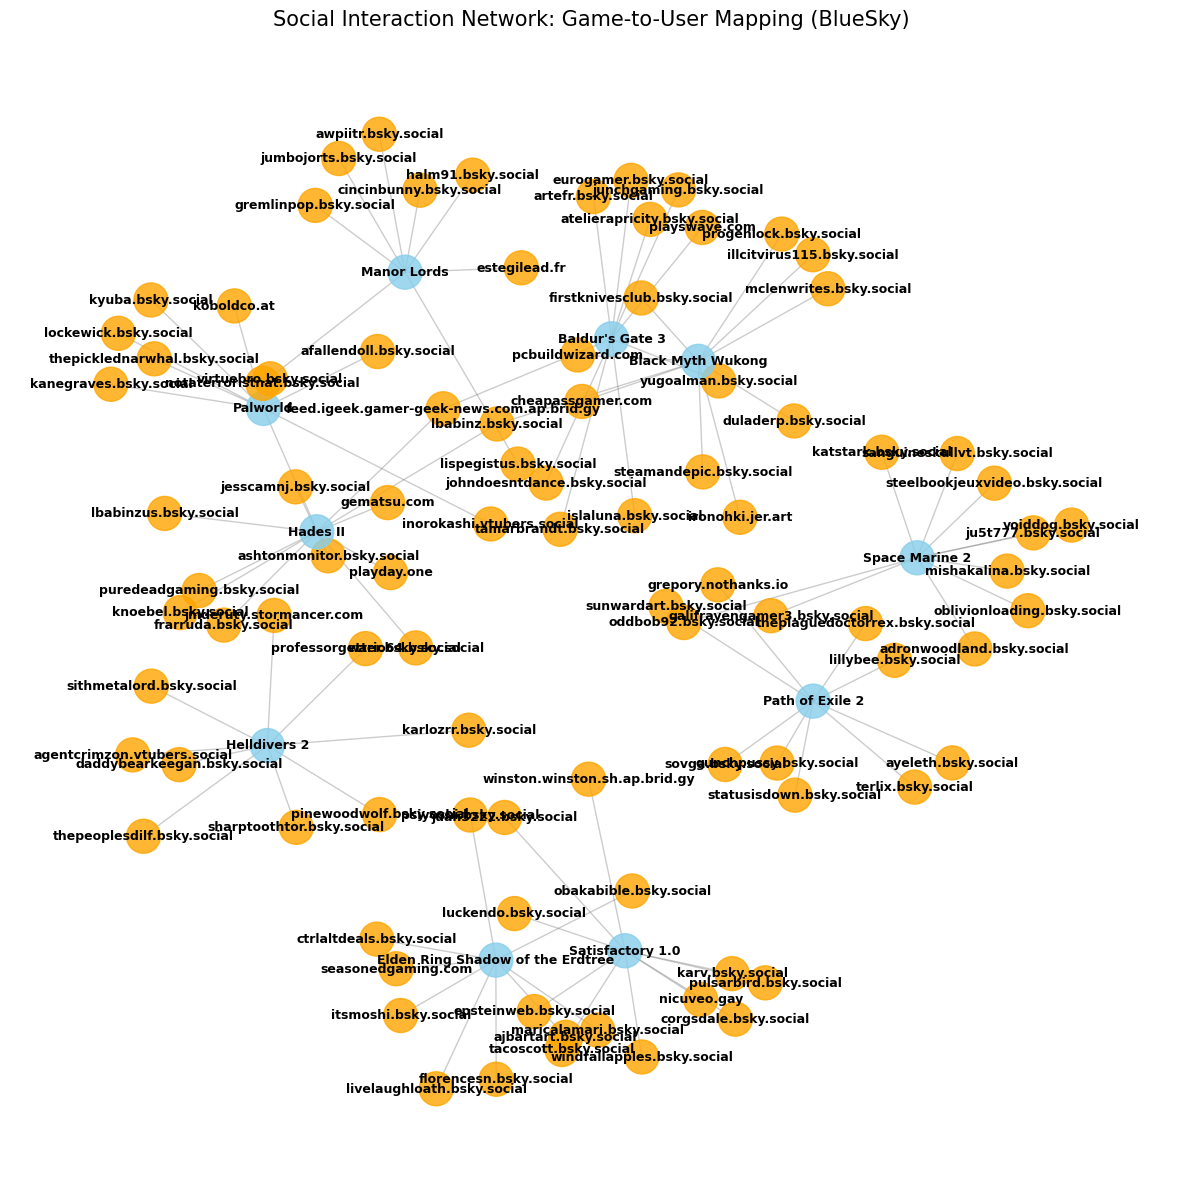

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import ast

# 1. Load your master data
df = pd.read_csv('FINAL_GAMING_DATASET_2026.csv', sep=';', decimal=',')

# 2. Initialize the Graph
G = nx.Graph()

print("🕸️ Building the Social Network Graph...")

# 3. Process each game and its users
for index, row in df.iterrows():
    game = row['game_name']
    # Convert the string list of authors back into a real Python list
    try:
        authors = row['nodes_list'].split(", ")
    except:
        continue

    # Add the Game as a central node
    G.add_node(game, type='game', color='skyblue')

    # Add users and connect them to the game
    # To keep the graph clean, we only take the first 10 users per game
    for author in authors[:10]:
        if author.strip():
            G.add_node(author, type='user', color='orange')
            G.add_edge(game, author)

# 4. Visualization Settings
plt.figure(figsize=(15, 15)) # Increased size for better resolution
pos = nx.spring_layout(G, k=0.3, iterations=50)

# Draw Nodes
node_colors = [G.nodes[n].get('color', 'lightgrey') for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, alpha=0.8)

# Draw Edges
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.4, edge_color='gray')

# Draw Labels
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title("Social Interaction Network: Game-to-User Mapping (BlueSky)", fontsize=15)
plt.axis('off')

# --- NEW LINE TO SAVE THE IMAGE ---
# This saves a high-quality PNG to your project folder
plt.savefig("bluesky_network_graph.png", dpi=300, bbox_inches='tight')
print("💾 Graph image saved as 'bluesky_network_graph.png'")

# Now show it on screen
plt.show()

In [ ]:
pip install wordcloud matplotlib

✅ Wordcloud saved as Space_Marine_2_wordcloud.png


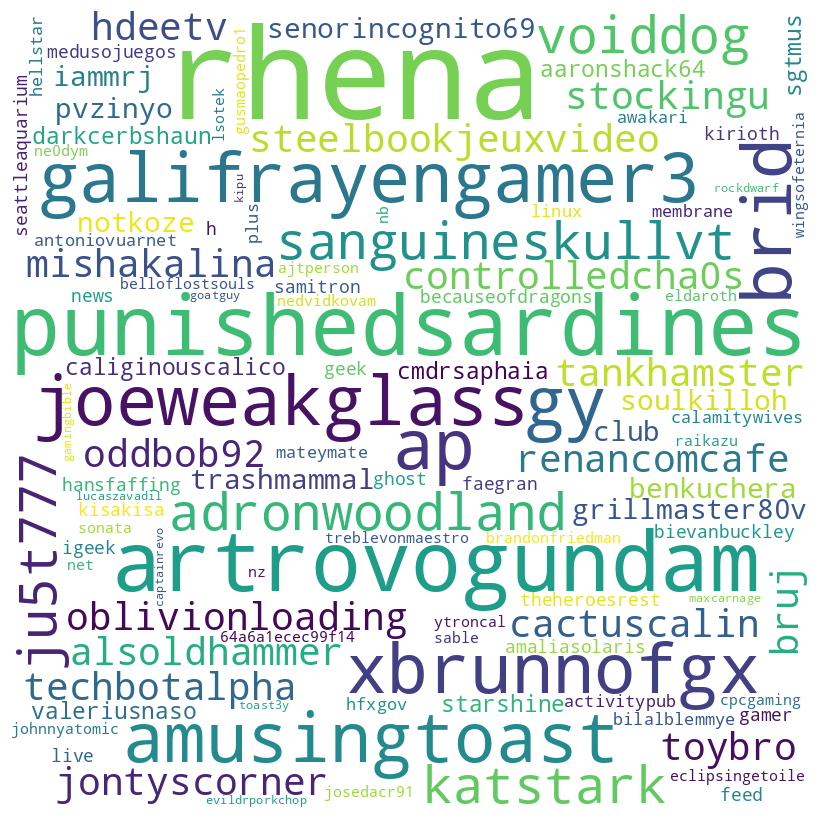

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# 1. Load your master data (where we saved the nodes_list/posts)
df = pd.read_csv('FINAL_GAMING_DATASET_2026.csv', sep=';', decimal=',')

def generate_game_wordcloud(game_target):
    # Filter the data for our target game
    game_data = df[df['game_name'] == game_target]

    if game_data.empty or pd.isna(game_data.iloc[0]['nodes_list']):
        print(f"No text data found for {game_target}")
        return

    # In our previous code, 'nodes_list' stored user handles.
    # For a real wordcloud, we'd use the actual post content.
    # Let's assume we saved the post text in a column called 'post_text'.
    # For this example, we will generate a cloud based on the names of people talking.
    text = game_data.iloc[0]['nodes_list'].replace(", ", " ")

    # 2. Setup Stopwords (words to ignore)
    comment_words = ''
    stopwords = set(STOPWORDS)
    # Adding custom gaming stopwords
    stopwords.update(["game", "play", "playing", "bsky", "social", "handle"])

    # 3. Create the WordCloud object
    wordcloud = WordCloud(
        width=800,
        height=800,
        background_color='white',
        stopwords=stopwords,
        min_font_size=10
    ).generate(text)

    # 4. Plot and Save
    plt.figure(figsize=(8, 8), facecolor=None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad=0)

    file_name = f"{game_target.replace(' ', '_')}_wordcloud.png"
    plt.savefig(file_name)
    print(f"✅ Wordcloud saved as {file_name}")
    plt.show()

# --- EXECUTION ---
# Let's generate it for the most popular game in your list
generate_game_wordcloud("Space Marine 2")